Here, we create the wedge figures for the total annual and cumulative GHG emissions in figure 6.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#defining GHG limits (see excel for sources etc.)
'''source carbon budget: IPCC (Rogelj et al. 2018: Mitigation Pathways Compatible with 1.5°C in the Context of Sustainable
Development. In: Global Warming of 1.5°C. An IPCC Special Report on the impacts of global warming of 1.5°C above
pre-industrial levels and related global greenhouse gas emission pathways, in the context of strengthening the global
response to the threat of climate change, sustainable development, and efforts to eradicate poverty '''
#based on 2/3 likelihood
#Unit=Gt from 2018 until 2050
onePointFiveDG=6.43
twoDG=17.92

In [3]:
#cumulative reference demand
file="Scenario results/Scenario results.xlsx"
data_refdemand_cum=pd.read_excel(file, sheet_name="GHG cum short L results", usecols='A:F', skiprows=2, nrows=33)
data_refdemand_cum.reset_index(drop=True, inplace=True)

#calculating wedges
delta_refdemand_cum_plus_using_scrap = data_refdemand_cum["Technologies BAU S-"] - data_refdemand_cum["Technologies BAU S+"]
delta_refdemand_cum_plus_tech = data_refdemand_cum["Technologies BAU S+"] - data_refdemand_cum["Improved technologies only"]
delta_refdemand_cum_plus_CR_and_Yield = data_refdemand_cum["Improved technologies only"] - data_refdemand_cum["Improved technologies and Alu-Cycle (CR +Yields)"]
delta_refdemand_cum_plus_Emix = data_refdemand_cum["Improved technologies and Alu-Cycle (CR +Yields)"] - data_refdemand_cum["Overall improvements"]
#data_refdemand_cum

In [4]:
#annual reference demand
file="Scenario results/Scenario results.xlsx"
data_refdemand_annual=pd.read_excel(file, sheet_name="GHG cum short L results", usecols='N:S', skiprows=2, nrows=33)
data_refdemand_annual.reset_index(drop=True, inplace=True)

#calculating wedges
delta_refdemand_annual_plus_using_scrap = data_refdemand_annual["Technologies BAU S-.1"] - data_refdemand_annual["Technologies BAU S+.1"]
delta_refdemand_annual_plus_tech = data_refdemand_annual["Technologies BAU S+.1"] - data_refdemand_annual["Improved technologies only.1"]
delta_refdemand_annual_plus_CR_and_Yield = data_refdemand_annual["Improved technologies only.1"] - data_refdemand_annual["Improved technologies and Alu-Cycle (CR +Yields).1"]
delta_refdemand_annual_plus_Emix = data_refdemand_annual["Improved technologies and Alu-Cycle (CR +Yields).1"] - data_refdemand_annual["Overall improvements.1"]

In [5]:
#colors
cmap = plt.cm.get_cmap('RdYlGn')
c1=cmap(0)
c2=cmap(0.25)
c3=cmap(0.5)
c4=cmap(0.75)

colors1=['#FF000000', 'FF000000', 'FF000000', 'FF000000', 'FF000000']
colors2=['#FF000000', 'FF000000', 'FF000000', 'FF000000', c1]
colors3=['#FF000000', 'FF000000', 'FF000000', c2, c1]
colors4=['#FF000000', 'FF000000', c3, c2, c1]
colors5=['#FF000000', c4, c3, c2, c1]

list_of_colors=[colors1, colors2, colors3, colors4, colors5]

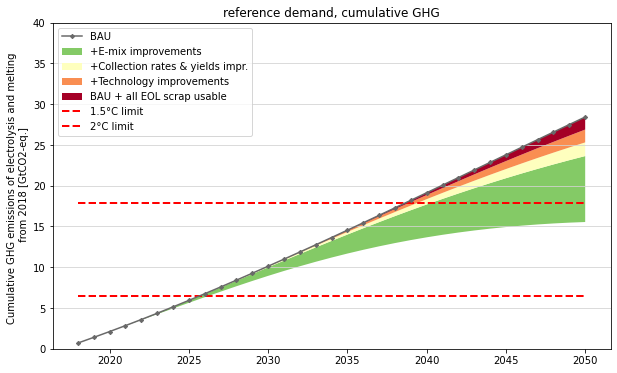

In [6]:
#plotting cumulative GHG wedges

fig=plt.figure(figsize = (10,6))

plt.stackplot(data_refdemand_cum.year, data_refdemand_cum["Overall improvements"], delta_refdemand_cum_plus_Emix, delta_refdemand_cum_plus_CR_and_Yield, delta_refdemand_cum_plus_tech, delta_refdemand_cum_plus_using_scrap, 
              labels=(['', '+E-mix improvements', '+Collection rates & yields impr.', '+Technology improvements', 'BAU + all EOL scrap usable']), colors=colors5, zorder=1)
plt.plot(data_refdemand_cum.year, data_refdemand_cum["Technologies BAU S-"], label='BAU', color='dimgrey', marker="D", ms=3)
plt.hlines(y=onePointFiveDG, xmin=2018, xmax=2050, colors='red', ls='--', lw=2, label='1.5°C limit')
plt.hlines(y=twoDG, xmin=2018, xmax=2050, colors='red', ls='--', lw=2, label='2°C limit')

plt.legend()
plt.ylabel("Cumulative GHG emissions of electrolysis and melting \n from 2018 [GtCO2-eq.]")
plt.ylim([0, 40])
plt.title('reference demand, cumulative GHG')
plt.grid(axis='y', color="lightgrey", zorder=-1)



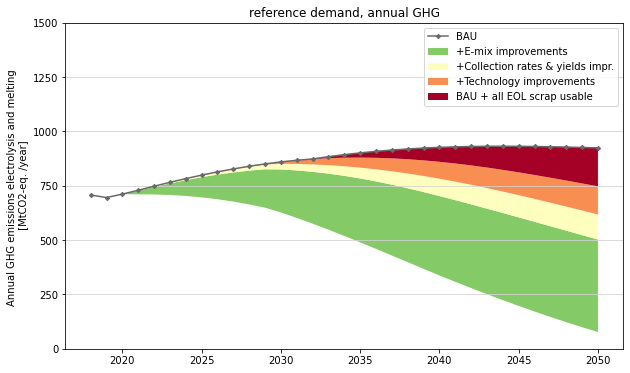

In [7]:
#plotting annual GHG wedges
fig=plt.figure(figsize = (10,6))
plt.stackplot(data_refdemand_annual['year.1'], data_refdemand_annual["Overall improvements.1"], delta_refdemand_annual_plus_Emix, delta_refdemand_annual_plus_CR_and_Yield, delta_refdemand_annual_plus_tech, delta_refdemand_annual_plus_using_scrap, 
              labels=(['', '+E-mix improvements', '+Collection rates & yields impr.', '+Technology improvements', 'BAU + all EOL scrap usable']), colors=colors5)
plt.plot(data_refdemand_annual['year.1'], data_refdemand_annual["Technologies BAU S-.1"], label='BAU', color='dimgrey', marker="D", ms=3)
plt.legend()
plt.ylabel("Annual GHG emissions electrolysis and melting \n [MtCO2-eq. /year]")
plt.yticks(np.arange(0, 1600, step=250))
plt.title('reference demand, annual GHG')
plt.grid(axis='y', color="lightgrey")

#plt.grid(color="lightgrey")

In [8]:
#and the same for the high demand

In [9]:
#cumulative high demand
file="Scenario results/Scenario results_high demand.xlsx"
data_highdemand_cum=pd.read_excel(file, sheet_name="GHG cum short L results", usecols='A:F', skiprows=2, nrows=33)
data_highdemand_cum.reset_index(drop=True, inplace=True)

#calculating wedges
delta_highdemand_cum_plus_using_scrap = data_highdemand_cum["Technologies BAU S-"] - data_highdemand_cum["Technologies BAU S+"]
delta_highdemand_cum_plus_tech = data_highdemand_cum["Technologies BAU S+"] - data_highdemand_cum["Improved technologies only"]
delta_highdemand_cum_plus_CR_and_Yield = data_highdemand_cum["Improved technologies only"] - data_highdemand_cum["Improved technologies and Alu-Cycle (CR +Yields)"]
delta_highdemand_cum_plus_Emix = data_highdemand_cum["Improved technologies and Alu-Cycle (CR +Yields)"] - data_highdemand_cum["Overall improvements"]


In [10]:
#annual high demand
file="Scenario results/Scenario results_high demand.xlsx"
data_highdemand_annual=pd.read_excel(file, sheet_name="GHG cum short L results", usecols='N:S', skiprows=2, nrows=33)
data_highdemand_annual.reset_index(drop=True, inplace=True)

#calculating wedges
delta_highdemand_annual_plus_using_scrap = data_highdemand_annual["Technologies BAU S-.1"] - data_highdemand_annual["Technologies BAU S+.1"]
delta_highdemand_annual_plus_tech = data_highdemand_annual["Technologies BAU S+.1"] - data_highdemand_annual["Improved technologies only.1"]
delta_highdemand_annual_plus_CR_and_Yield = data_highdemand_annual["Improved technologies only.1"] - data_highdemand_annual["Improved technologies and Alu-Cycle (CR +Yields).1"]
delta_highdemand_annual_plus_Emix = data_highdemand_annual["Improved technologies and Alu-Cycle (CR +Yields).1"] - data_highdemand_annual["Overall improvements.1"]

In [11]:
#calculating wedges
delta_highdemand_annual_plus_using_scrap = data_highdemand_annual["Technologies BAU S-.1"] - data_highdemand_annual["Technologies BAU S+.1"]
delta_highdemand_annual_plus_tech = data_highdemand_annual["Technologies BAU S+.1"] - data_highdemand_annual["Improved technologies only.1"]
delta_highdemand_annual_plus_CR_and_Yield = data_highdemand_annual["Improved technologies only.1"] - data_highdemand_annual["Improved technologies and Alu-Cycle (CR +Yields).1"]
delta_highdemand_annual_plus_Emix = data_highdemand_annual["Improved technologies and Alu-Cycle (CR +Yields).1"] - data_highdemand_annual["Overall improvements.1"]

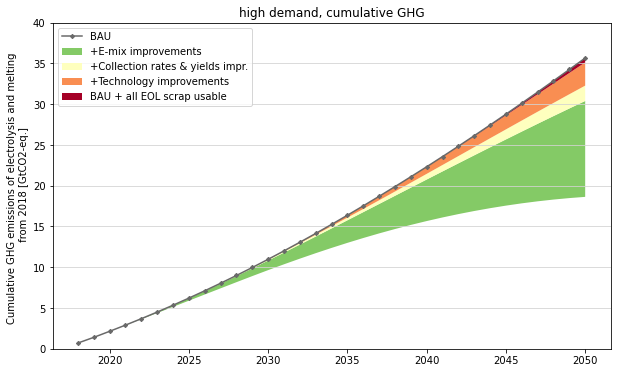

In [12]:
#plotting cumulative GHG wedges

fig=plt.figure(figsize = (10,6))
plt.stackplot(data_highdemand_cum.year, data_highdemand_cum["Overall improvements"], delta_highdemand_cum_plus_Emix, delta_highdemand_cum_plus_CR_and_Yield, delta_highdemand_cum_plus_tech, delta_highdemand_cum_plus_using_scrap, 
              labels=(['', '+E-mix improvements', '+Collection rates & yields impr.', '+Technology improvements', 'BAU + all EOL scrap usable']), colors=colors5)
plt.plot(data_highdemand_cum.year, data_highdemand_cum["Technologies BAU S-"], label='BAU', color='dimgrey', marker="D", ms=3)
plt.legend()
plt.ylabel("Cumulative GHG emissions of electrolysis and melting \n from 2018 [GtCO2-eq.]")
plt.ylim([0, 40])
plt.title('high demand, cumulative GHG')
plt.grid(axis='y', color="lightgrey")


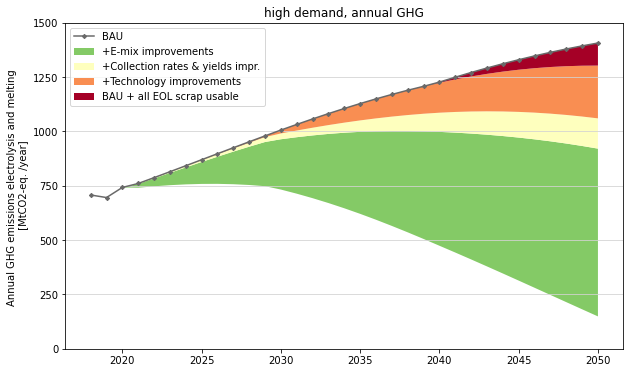

In [13]:
#plotting annual GHG wedges
fig=plt.figure(figsize = (10,6))
plt.stackplot(data_highdemand_annual['year.1'], data_highdemand_annual["Overall improvements.1"], delta_highdemand_annual_plus_Emix, delta_highdemand_annual_plus_CR_and_Yield, delta_highdemand_annual_plus_tech, delta_highdemand_annual_plus_using_scrap, 
              labels=(['', '+E-mix improvements', '+Collection rates & yields impr.', '+Technology improvements', 'BAU + all EOL scrap usable']), colors=colors5)
plt.plot(data_highdemand_annual['year.1'], data_highdemand_annual["Technologies BAU S-.1"], label='BAU', color='dimgrey', marker="D", ms=3)
plt.legend()
plt.ylabel("Annual GHG emissions electrolysis and melting \n [MtCO2-eq. /year]")
plt.ylim([0, 1500])
plt.yticks(np.arange(0, 1600, step=250))
plt.title('high demand, annual GHG')
plt.grid(axis='y', color="lightgrey")

#plt.grid(color="lightgrey")

One figure for all 4

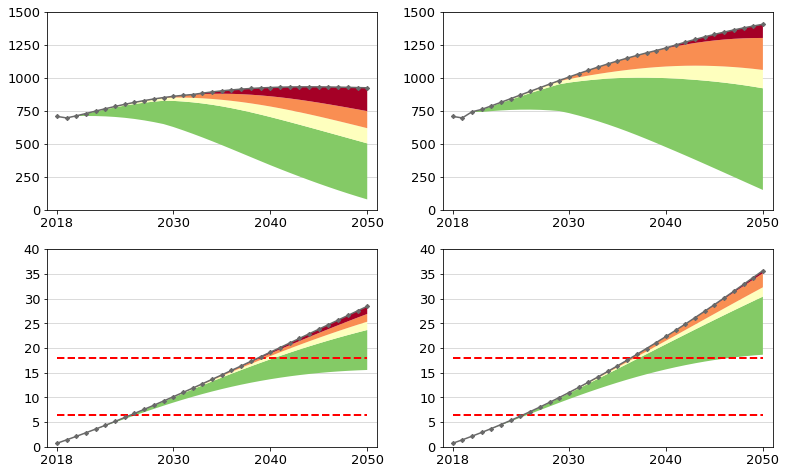

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(13,8))

#annual GHG - reference demand
axs[0,0].stackplot(data_refdemand_annual['year.1'], data_refdemand_annual["Overall improvements.1"], delta_refdemand_annual_plus_Emix, delta_refdemand_annual_plus_CR_and_Yield, delta_refdemand_annual_plus_tech, delta_refdemand_annual_plus_using_scrap, 
              labels=(['empty', '+E-mix improvements', '+Collection rates & yields impr.', '+Technology improvements', 'BAU + all EOL scrap usable']), colors=colors5)
axs[0,0].plot(data_refdemand_annual['year.1'], data_refdemand_annual["Technologies BAU S-.1"], label='BAU', color='dimgrey', marker="D", ms=3)
#axs[0,0].set_ylabel('Annual GHG emissions electrolysis and melting \n [MtCO2-eq. /year]')
axs[0,0].grid(axis='y', color="lightgrey")
axs[0,0].set_axisbelow(True)
axs[0,0].set_yticks(np.arange(0, 1501, step=250))
axs[0,0].set_xticks([2018]+list(np.arange(2030,2050)[::10])+[2050])
axs[0,0].set_xlim([2017,2051])
axs[0,0].tick_params(axis='both', which='major', labelsize=13)
#fontdict={'fontweight':'bold','fontsize':15}
'''axs[0,0].spines['top'].set_color('lightgrey')
axs[0,0].spines['bottom'].set_color('lightgrey')
axs[0,0].spines['left'].set_color('lightgrey')
axs[0,0].spines['right'].set_color('lightgrey')
'''

#annual GHG - high demand
axs[0,1].stackplot(data_highdemand_annual['year.1'], data_highdemand_annual["Overall improvements.1"], delta_highdemand_annual_plus_Emix, delta_highdemand_annual_plus_CR_and_Yield, delta_highdemand_annual_plus_tech, delta_highdemand_annual_plus_using_scrap, 
              labels=(['empty', '+E-mix improvements', '+Collection rates & yields impr.', '+Technology improvements', 'BAU + all EOL scrap usable']), colors=colors5)
axs[0,1].plot(data_highdemand_annual['year.1'], data_highdemand_annual["Technologies BAU S-.1"], label='BAU', color='dimgrey', marker="D", ms=3)
#axs[0,1].set_ylabel('Annual GHG emissions electrolysis and melting \n [MtCO2-eq. /year]')
axs[0,1].grid(axis='y', color="lightgrey")
axs[0,1].set_axisbelow(True)
axs[0,1].set_yticks(np.arange(0, 1501, step=250))
axs[0,1].set_xticks([2018]+list(np.arange(2030,2050)[::10])+[2050])
axs[0,1].set_xlim([2017,2051])
axs[0,1].tick_params(axis='both', which='major', labelsize=13)


#cumulative GHG - reference demand
axs[1,0].stackplot(data_refdemand_cum['year'], data_refdemand_cum["Overall improvements"], delta_refdemand_cum_plus_Emix, delta_refdemand_cum_plus_CR_and_Yield, delta_refdemand_cum_plus_tech, delta_refdemand_cum_plus_using_scrap, 
              labels=(['empty', '+E-mix improvements', '+Collection rates & yields impr.', '+Technology improvements', 'BAU + all EOL scrap usable']), colors=colors5)
axs[1,0].plot(data_refdemand_cum['year'], data_refdemand_cum["Technologies BAU S-"], label='BAU', color='dimgrey', marker="D", ms=3)
#axs[1,0].set_ylabel('Cumulative GHG emissions electrolysis and melting \n [MtCO2-eq. /year]')
#axs[1,0].set_xlabel('Year')
axs[1,0].hlines(y=onePointFiveDG, xmin=2018, xmax=2050, colors='red', ls='--', lw=2, label='1.5°C limit')
axs[1,0].hlines(y=twoDG, xmin=2018, xmax=2050, colors='red', linestyle='--', lw=2, label='2°C limit')
axs[1,0].grid(axis='y', color="lightgrey")
axs[1,0].set_axisbelow(True)
axs[1,0].set_yticks(np.arange(0, 41, step=5))
axs[1,0].set_xticks([2018]+list(np.arange(2030,2050)[::10])+[2050])
axs[1,0].set_xlim([2017,2051])
axs[1,0].tick_params(axis='both', which='major', labelsize=13)

#cumulative GHG - high demand
axs[1,1].stackplot(data_highdemand_cum['year'], data_highdemand_cum["Overall improvements"], delta_highdemand_cum_plus_Emix, delta_highdemand_cum_plus_CR_and_Yield, delta_highdemand_cum_plus_tech, delta_highdemand_cum_plus_using_scrap, 
              labels=(['empty', '+E-mix improvements', '+Collection rates & yields impr.', '+Technology improvements', 'BAU + all EOL scrap usable']), colors=colors5)
axs[1,1].plot(data_highdemand_cum['year'], data_highdemand_cum["Technologies BAU S-"], label='BAU', color='dimgrey', marker="D", ms=3)
#axs[1,1].set_ylabel('Cumulative GHG emissions electrolysis and melting \n [MtCO2-eq. /year]')
#axs[1,1].set_xlabel('Year')
axs[1,1].hlines(y=onePointFiveDG, xmin=2018, xmax=2050, colors='red', ls='--', lw=2, label='1.5°C limit')
axs[1,1].hlines(y=twoDG, xmin=2018, xmax=2050, colors='red', linestyle='--', lw=2, label='2°C limit')
axs[1,1].grid(axis='y', color="lightgrey")
axs[1,1].set_axisbelow(True)
axs[1,1].set_yticks(np.arange(0, 41, step=5))
axs[1,1].set_xticks([2018]+list(np.arange(2030,2050)[::10])+[2050])
axs[1,1].set_xlim([2017,2051])
axs[1,1].tick_params(axis='both', which='major', labelsize=13)


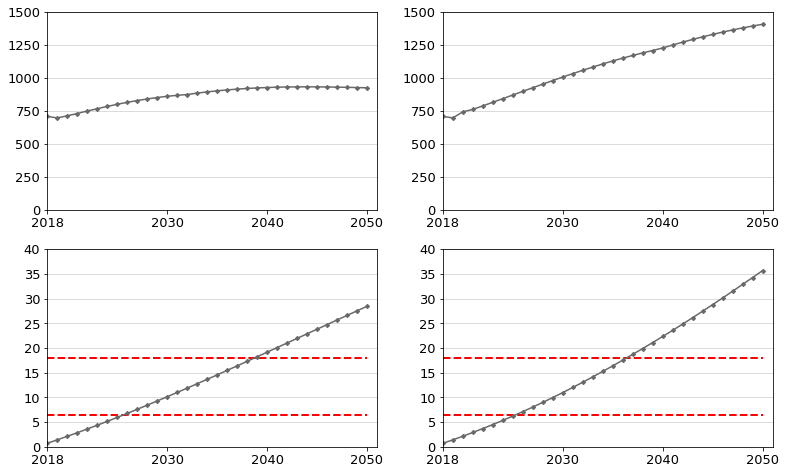

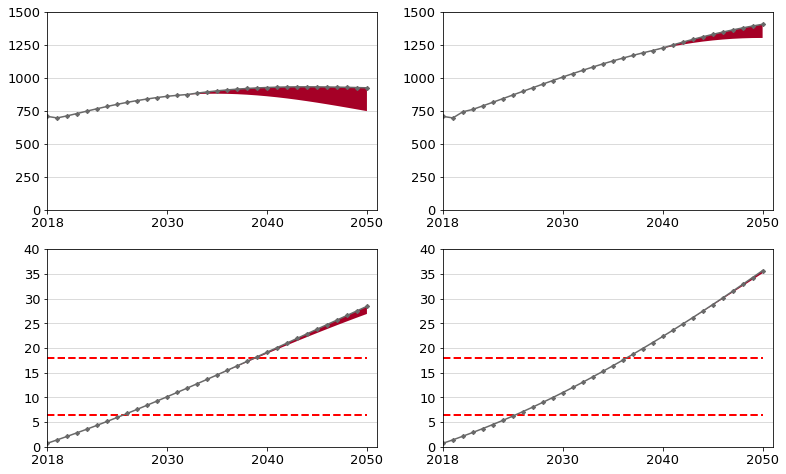

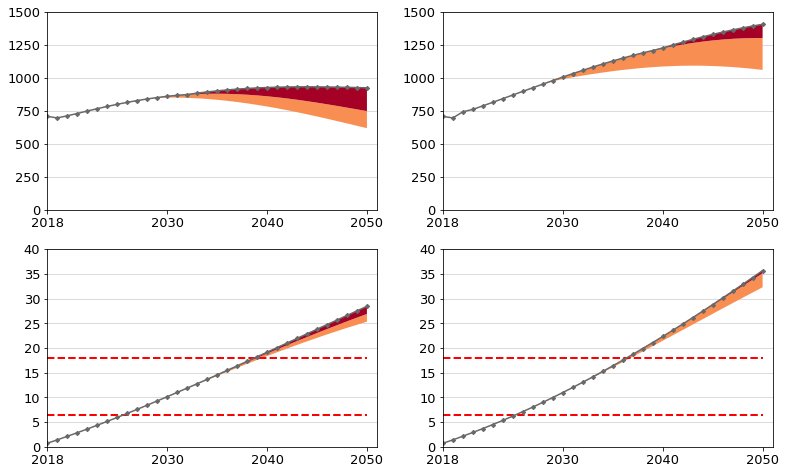

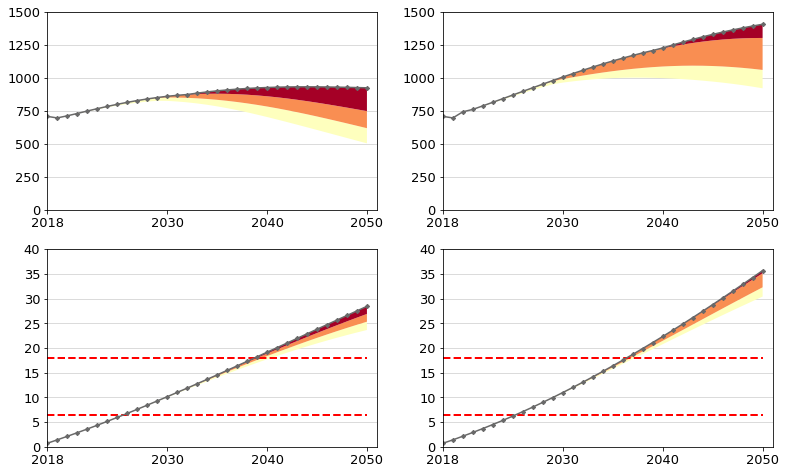

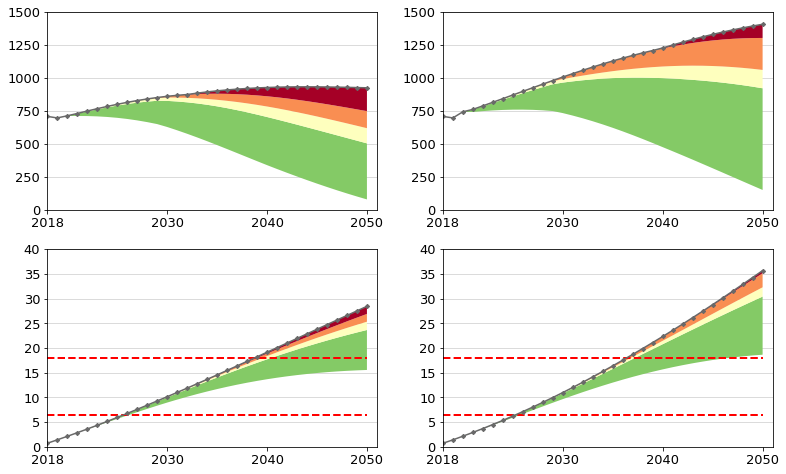

In [15]:
x=0
for i in list_of_colors:
    
    name='GHG '+str(x)
    x+=1
    fig, axs = plt.subplots(2, 2, figsize=(13,8))

    #annual GHG - reference demand
    axs[0,0].stackplot(data_refdemand_annual['year.1'], data_refdemand_annual["Overall improvements.1"], delta_refdemand_annual_plus_Emix, delta_refdemand_annual_plus_CR_and_Yield, delta_refdemand_annual_plus_tech, delta_refdemand_annual_plus_using_scrap, 
                labels=(['empty', '+E-mix improvements', '+Collection rates & yields impr.', '+Technology improvements', 'BAU + all EOL scrap usable']), colors=i)
    axs[0,0].plot(data_refdemand_annual['year.1'], data_refdemand_annual["Technologies BAU S-.1"], label='BAU', color='dimgrey', marker="D", ms=3)
    #axs[0,0].set_ylabel('Annual GHG emissions electrolysis and melting \n [MtCO2-eq. /year]')
    axs[0,0].grid(axis='y', color="lightgrey")
    axs[0,0].set_axisbelow(True)
    axs[0,0].set_yticks(np.arange(0, 1501, step=250))
    axs[0,0].set_xticks([2018]+list(np.arange(2030,2050)[::10])+[2050])
    axs[0,0].set_xlim([2018,2051])
    axs[0,0].tick_params(axis='both', which='major', labelsize=13)
    #fontdict={'fontweight':'bold','fontsize':15}
    '''axs[0,0].spines['top'].set_color('lightgrey')
    axs[0,0].spines['bottom'].set_color('lightgrey')
    axs[0,0].spines['left'].set_color('lightgrey')
    axs[0,0].spines['right'].set_color('lightgrey')
    '''

    #annual GHG - high demand
    axs[0,1].stackplot(data_highdemand_annual['year.1'], data_highdemand_annual["Overall improvements.1"], delta_highdemand_annual_plus_Emix, delta_highdemand_annual_plus_CR_and_Yield, delta_highdemand_annual_plus_tech, delta_highdemand_annual_plus_using_scrap, 
                labels=(['empty', '+E-mix improvements', '+Collection rates & yields impr.', '+Technology improvements', 'BAU + all EOL scrap usable']), colors=i)
    axs[0,1].plot(data_highdemand_annual['year.1'], data_highdemand_annual["Technologies BAU S-.1"], label='BAU', color='dimgrey', marker="D", ms=3)
    #axs[0,1].set_ylabel('Annual GHG emissions electrolysis and melting \n [MtCO2-eq. /year]')
    axs[0,1].grid(axis='y', color="lightgrey")
    axs[0,1].set_axisbelow(True)
    axs[0,1].set_yticks(np.arange(0, 1501, step=250))
    axs[0,1].set_xticks([2018]+list(np.arange(2030,2050)[::10])+[2050])
    axs[0,1].set_xlim([2018,2051])
    axs[0,1].tick_params(axis='both', which='major', labelsize=13)


    #cumulative GHG - reference demand
    axs[1,0].stackplot(data_refdemand_cum['year'], data_refdemand_cum["Overall improvements"], delta_refdemand_cum_plus_Emix, delta_refdemand_cum_plus_CR_and_Yield, delta_refdemand_cum_plus_tech, delta_refdemand_cum_plus_using_scrap, 
                labels=(['empty', '+E-mix improvements', '+Collection rates & yields impr.', '+Technology improvements', 'BAU + all EOL scrap usable']), colors=i)
    axs[1,0].plot(data_refdemand_cum['year'], data_refdemand_cum["Technologies BAU S-"], label='BAU', color='dimgrey', marker="D", ms=3)
    #axs[1,0].set_ylabel('Cumulative GHG emissions electrolysis and melting \n [MtCO2-eq. /year]')
    #axs[1,0].set_xlabel('Year')
    axs[1,0].hlines(y=onePointFiveDG, xmin=2018, xmax=2050, colors='red', ls='--', lw=2, label='1.5°C limit')
    axs[1,0].hlines(y=twoDG, xmin=2018, xmax=2050, colors='red', linestyle='--', lw=2, label='2°C limit')
    axs[1,0].grid(axis='y', color="lightgrey")
    axs[1,0].set_axisbelow(True)
    axs[1,0].set_yticks(np.arange(0, 41, step=5))
    axs[1,0].set_xticks([2018]+list(np.arange(2030,2050)[::10])+[2050])
    axs[1,0].set_xlim([2018,2051])
    axs[1,0].tick_params(axis='both', which='major', labelsize=13)

    #cumulative GHG - high demand
    axs[1,1].stackplot(data_highdemand_cum['year'], data_highdemand_cum["Overall improvements"], delta_highdemand_cum_plus_Emix, delta_highdemand_cum_plus_CR_and_Yield, delta_highdemand_cum_plus_tech, delta_highdemand_cum_plus_using_scrap, 
                labels=(['empty', '+E-mix improvements', '+Collection rates & yields impr.', '+Technology improvements', 'BAU + all EOL scrap usable']), colors=i)
    axs[1,1].plot(data_highdemand_cum['year'], data_highdemand_cum["Technologies BAU S-"], label='BAU', color='dimgrey', marker="D", ms=3)
    #axs[1,1].set_ylabel('Cumulative GHG emissions electrolysis and melting \n [MtCO2-eq. /year]')
    #axs[1,1].set_xlabel('Year')
    axs[1,1].hlines(y=onePointFiveDG, xmin=2018, xmax=2050, colors='red', ls='--', lw=2, label='1.5°C limit')
    axs[1,1].hlines(y=twoDG, xmin=2018, xmax=2050, colors='red', linestyle='--', lw=2, label='2°C limit')
    axs[1,1].grid(axis='y', color="lightgrey")
    axs[1,1].set_axisbelow(True)
    axs[1,1].set_yticks(np.arange(0, 41, step=5))
    axs[1,1].set_xticks([2018]+list(np.arange(2030,2050)[::10])+[2050])
    axs[1,1].set_xlim([2018,2051])
    axs[1,1].tick_params(axis='both', which='major', labelsize=13)

    plt.savefig("Scenario results/Figures/"+name, dpi=1200)
